In [1]:
import pandas as pd
import numpy as np

In [2]:
import sys
!{sys.executable} -m pip install seaborn


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
#Data viz packages
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [4]:
import sys
!{sys.executable} -m pip install nltk wordcloud


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
#NLP
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
from wordcloud import WordCloud

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\imdb_processed1.csv")


In [7]:
df.head()

,Unnamed: 0,title,year,rating,vote,runtime,genre,country,language,kind,director,cast,writer,composer
0,0,The Shawshank Redemption,1994.0,9.3,2700000.0,142.0,['Drama'],['USA'],['English'],movie,['Frank Darabont'],"['Tim Robbins', 'Morgan Freeman', 'Bob Gunton']",['Stephen King'],Composer_1
1,1,The Godfather,1972.0,9.2,1900000.0,175.0,"['Crime', 'Drama']",['USA'],"['English', 'Italian']",movie,['Francis Ford Coppola'],"['Marlon Brando', 'Al Pacino', 'James Caan']",['Mario Puzo'],Composer_2
2,2,The Dark Knight,2008.0,9.0,2600000.0,152.0,"['Action', 'Crime', 'Drama']","['USA', 'UK']",['English'],movie,['Christopher Nolan'],"['Christian Bale', 'Heath Ledger', 'Aaron Eckh...",['Christopher Nolan'],Composer_3
3,3,Schindler's List,1993.0,9.0,1400000.0,195.0,"['Biography', 'Drama', 'History']",['USA'],"['English', 'German']",movie,['Steven Spielberg'],"['Liam Neeson', 'Ralph Fiennes', 'Ben Kingsley']",['Steven Zaillian'],Composer_4
4,4,12 Angry Men,1957.0,9.0,840000.0,96.0,"['Crime', 'Drama']",['USA'],['English'],movie,['Sidney Lumet'],"['Henry Fonda', 'Lee J. Cobb', 'Martin Balsam']",['Reginald Rose'],Composer_5


## Data Pre-Processing

In [8]:
#view the list of columns
df.columns

Index(['Unnamed: 0', 'title', 'year', 'rating', 'vote', 'runtime', 'genre',
       'country', 'language', 'kind', 'director', 'cast', 'writer',
       'composer'],
      dtype='str')

In [9]:
#dropping unnamed column
df = df.drop("Unnamed: 0",axis=1)

In [10]:
#view the list of columns
df.columns

Index(['title', 'year', 'rating', 'vote', 'runtime', 'genre', 'country',
       'language', 'kind', 'director', 'cast', 'writer', 'composer'],
      dtype='str')

In [11]:
#no of rows and columns
df.shape

(232, 13)

In [12]:
#checking for no of missing values 
df.isnull().sum()

title        0
year         0
rating      11
vote        11
runtime     12
genre        6
country      7
language     7
kind         0
director     7
cast         7
writer       7
composer     0
dtype: int64

In [13]:
#replacing Nan with mean value in numeric columns
df[['rating', 'vote', 'runtime']] = df[['rating', 'vote', 'runtime']].fillna(df[['rating', 'vote', 'runtime']].mean())

In [14]:
#dropping nan rows
df.dropna(inplace=True)

In [15]:
#checking for no of missing values 
df.isnull().sum()

title       0
year        0
rating      0
vote        0
runtime     0
genre       0
country     0
language    0
kind        0
director    0
cast        0
writer      0
composer    0
dtype: int64

In [16]:
#check datatypes
df.dtypes

title           str
year        float64
rating      float64
vote        float64
runtime     float64
genre           str
country         str
language        str
kind            str
director        str
cast            str
writer          str
composer        str
dtype: object

In [17]:
#converting 'year', 'runtime' and 'vote' from float to int

columns = ['year','runtime','vote']

for column in columns:
    df[column] = df[column].astype(int)

In [18]:
#check datatypes
df.dtypes

title           str
year          int64
rating      float64
vote          int64
runtime       int64
genre           str
country         str
language        str
kind            str
director        str
cast            str
writer          str
composer        str
dtype: object

In [19]:
#creating a composite key using title and release year
#add the 'Composite_Key' column
df['id'] = df['title'] + '_' + df['year'].astype(str)

#move 'Composite_Key' column to the beginning
df = df[['id'] + [col for col in df.columns if col != 'id']]

#view the list of columns
df.columns

Index(['id', 'title', 'year', 'rating', 'vote', 'runtime', 'genre', 'country',
       'language', 'kind', 'director', 'cast', 'writer', 'composer'],
      dtype='str')

In [20]:
#remove brackets from genre, country, language, director, cast and writer columns

columns = ['genre','country','language','cast','director','writer']

for column in columns:
    df[column] = df[column].astype(str).str.strip('[]')

In [21]:
#remove quotes from genre, country, language, director, cast, writer columns

quote_columns = ['genre','country','language','cast','director','writer']

for quote in quote_columns:
    df[quote] = df[quote].str.replace(r"\'","", regex=True)

In [22]:
df.head()

,id,title,year,rating,vote,runtime,genre,country,language,kind,director,cast,writer,composer
0,The Shawshank Redemption_1994,The Shawshank Redemption,1994,9.3,2700000,142,Drama,USA,English,movie,Frank Darabont,"Tim Robbins, Morgan Freeman, Bob Gunton",Stephen King,Composer_1
1,The Godfather_1972,The Godfather,1972,9.2,1900000,175,"Crime, Drama",USA,"English, Italian",movie,Francis Ford Coppola,"Marlon Brando, Al Pacino, James Caan",Mario Puzo,Composer_2
2,The Dark Knight_2008,The Dark Knight,2008,9.0,2600000,152,"Action, Crime, Drama","USA, UK",English,movie,Christopher Nolan,"Christian Bale, Heath Ledger, Aaron Eckhart",Christopher Nolan,Composer_3
3,Schindler's List_1993,Schindler's List,1993,9.0,1400000,195,"Biography, Drama, History",USA,"English, German",movie,Steven Spielberg,"Liam Neeson, Ralph Fiennes, Ben Kingsley",Steven Zaillian,Composer_4
4,12 Angry Men_1957,12 Angry Men,1957,9.0,840000,96,"Crime, Drama",USA,English,movie,Sidney Lumet,"Henry Fonda, Lee J. Cobb, Martin Balsam",Reginald Rose,Composer_5


In [23]:
#rename column
df.rename(columns = {'kind':'category'}, inplace = True)

In [24]:
df.columns

Index(['id', 'title', 'year', 'rating', 'vote', 'runtime', 'genre', 'country',
       'language', 'category', 'director', 'cast', 'writer', 'composer'],
      dtype='str')

In [25]:
#dropping extra columns
column_to_drop = ['composer']
df.drop(column_to_drop, axis=1, inplace=True)
df.columns

Index(['id', 'title', 'year', 'rating', 'vote', 'runtime', 'genre', 'country',
       'language', 'category', 'director', 'cast', 'writer'],
      dtype='str')

In [26]:
#check for no of duplicates present
len(df)-len(df.drop_duplicates())

7

In [27]:
#Dropping duplicates based on id column
df = df.drop_duplicates('id').sort_index()

In [28]:
#check for no of duplicates present
len(df)-len(df.drop_duplicates())

0

In [29]:
df.shape

(190, 13)

In [30]:
df["category"].value_counts()

category
movie             160
tv series          28
tv mini series      2
Name: count, dtype: int64

In [31]:
df_new = df[~df['category'].isin(['tv short', 'video game'])]
df_new["category"].value_counts()

category
movie             160
tv series          28
tv mini series      2
Name: count, dtype: int64

In [32]:
#replacing 'tv movies', 'video movie' to 'movie'
df_new.replace(regex=r'tv movie', value='movie', inplace=True)
df_new.replace(regex=r'video movie', value='movie', inplace=True)
df_new["category"].value_counts()

category
movie             160
tv series          28
tv mini series      2
Name: count, dtype: int64

In [33]:
df_new.head()

,id,title,year,rating,vote,runtime,genre,country,language,category,director,cast,writer
0,The Shawshank Redemption_1994,The Shawshank Redemption,1994,9.3,2700000,142,Drama,USA,English,movie,Frank Darabont,"Tim Robbins, Morgan Freeman, Bob Gunton",Stephen King
1,The Godfather_1972,The Godfather,1972,9.2,1900000,175,"Crime, Drama",USA,"English, Italian",movie,Francis Ford Coppola,"Marlon Brando, Al Pacino, James Caan",Mario Puzo
2,The Dark Knight_2008,The Dark Knight,2008,9.0,2600000,152,"Action, Crime, Drama","USA, UK",English,movie,Christopher Nolan,"Christian Bale, Heath Ledger, Aaron Eckhart",Christopher Nolan
3,Schindler's List_1993,Schindler's List,1993,9.0,1400000,195,"Biography, Drama, History",USA,"English, German",movie,Steven Spielberg,"Liam Neeson, Ralph Fiennes, Ben Kingsley",Steven Zaillian
4,12 Angry Men_1957,12 Angry Men,1957,9.0,840000,96,"Crime, Drama",USA,English,movie,Sidney Lumet,"Henry Fonda, Lee J. Cobb, Martin Balsam",Reginald Rose


In [34]:
df_new.to_csv('cleaned_imdb_dataset.csv')

# Exploratory Data Analysis (EDA)

## Top 10 Best Perfoming Movies

C:\Users\DELL\AppData\Local\Temp\ipykernel_22572\2036710101.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot = ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)


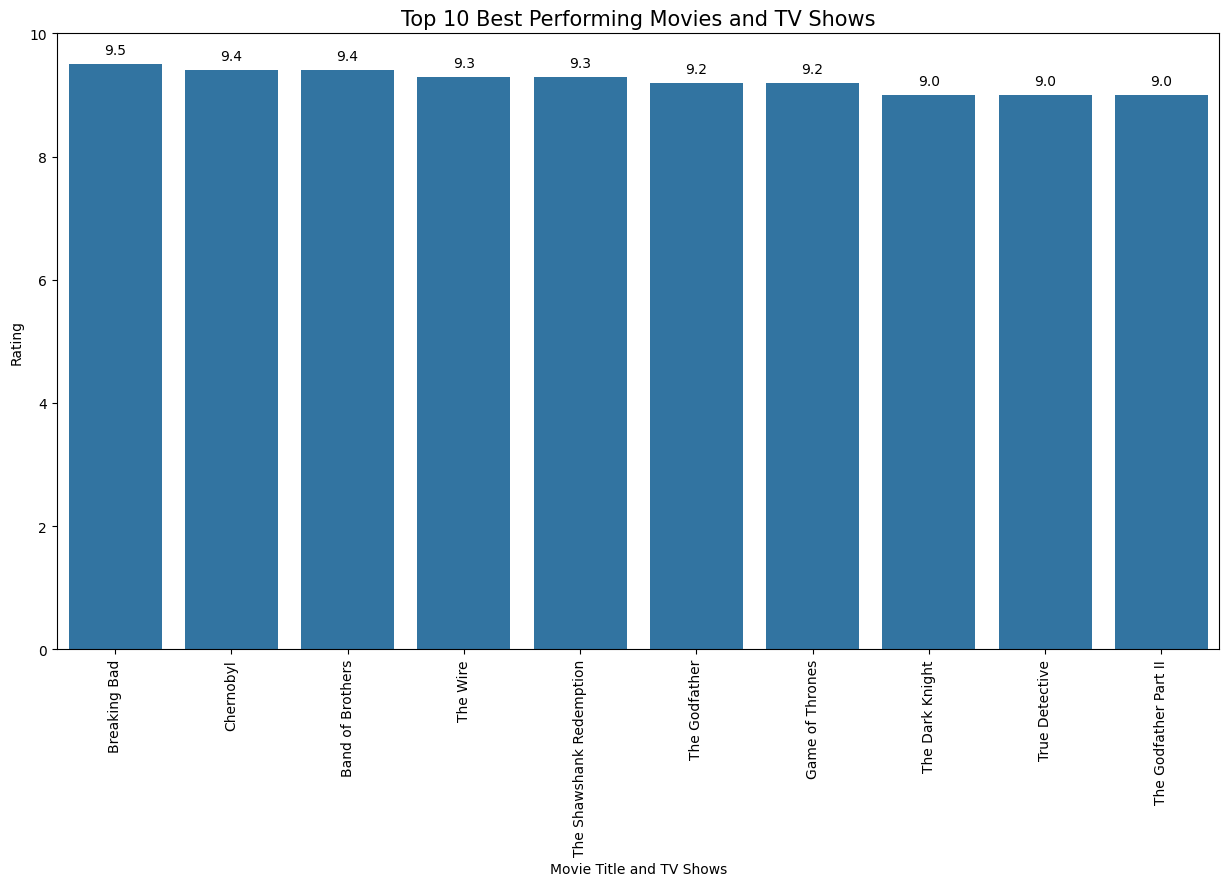

In [35]:
fig = plt.figure(figsize = (15, 8))
ax = sns.barplot(x = 'title', y = 'rating', data = df_new.sort_values('rating', ascending=False)[0:10])

# Plot the ratings on top of the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), 
                textcoords = 'offset points')
    
plot = ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)
plt.xlabel('Movie Title and TV Shows')
plt.ylabel('Rating')
plt.title('Top 10 Best Performing Movies and TV Shows', fontsize = 15)

# Set y-axis ticks
plt.yticks([0, 2, 4, 6, 8, 10])

plt.show()

## Distribution of Category

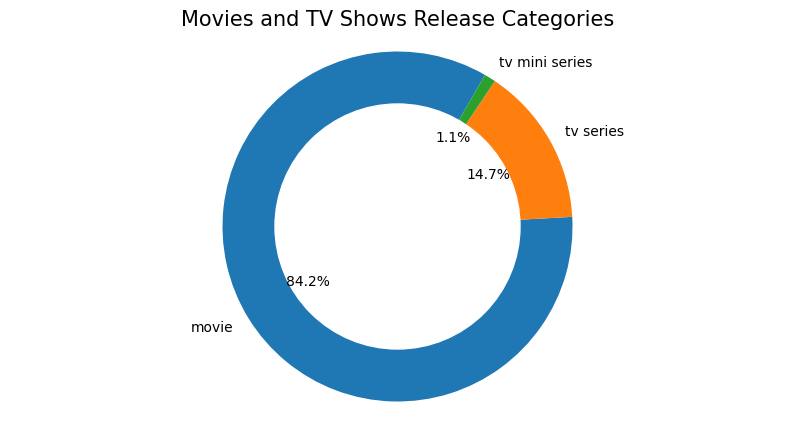

In [36]:
# Compute counts for each category
category_counts = df_new['category'].value_counts()

# Plotting
plt.figure(figsize=(10, 5))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=60, wedgeprops=dict(width=0.4))
plt.title("Movies and TV Shows Release Categories", fontsize=15)
plt.gca().add_artist(plt.Circle((0, 0), 0.7, color='white'))  # Add a white circle to create a donut chart effect
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

## Genre with the most releases

In [37]:
genres_series = df_new['genre'].str.split(',\s*').explode()

# Count the occurrences of each genre
genre_counts = genres_series.value_counts().reset_index()

# Rename columns
genre_counts.columns = ['genre', 'count']
genre_counts.head()

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\DELL\AppData\Local\Temp\ipykernel_22572\331481654.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  genres_series = df_new['genre'].str.split(',\s*').explode()


,genre,count
0,Drama,159
1,Crime,35
2,Comedy,35
3,Action,31
4,Adventure,31


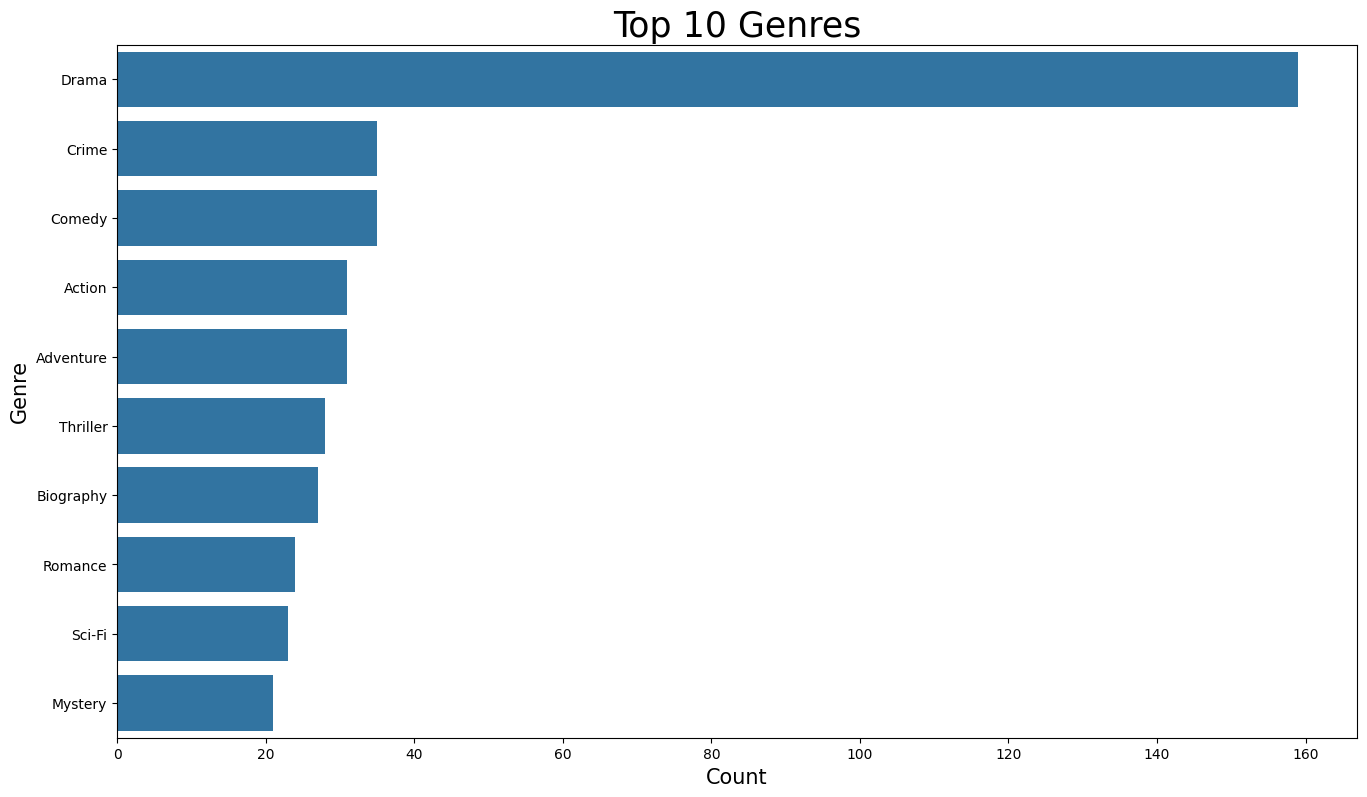

In [38]:
plt.figure(figsize = (16, 9))
ax = sns.barplot(x = 'count', y = 'genre', data = genre_counts.sort_values('count', ascending=False)[0:10])
plt.title("Top 10 Genres", fontsize = 25)
plt.xlabel('Count', fontsize = 15)
plt.ylabel('Genre', fontsize = 15)
plt.show()

## Total number of releases each year

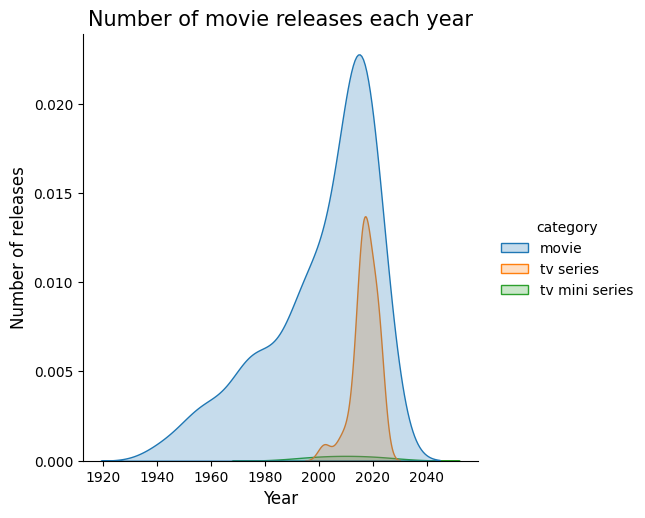

In [39]:
sns.displot(df_new, x="year", hue="category", kind="kde", fill=True)
plt.title("Number of movie releases each year", fontsize = 15)
plt.ylabel('Number of releases', fontsize = 12)
plt.xlabel('Year', fontsize = 12)
plt.show()

## Top 10 countries with most releases

In [40]:
country_series = df_new['country'].str.split(',\s*').explode()

# Count the occurrences of each genre
country_counts = country_series.value_counts().reset_index()

# Rename columns
country_counts.columns = ['country', 'count']
country_counts.head()

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\DELL\AppData\Local\Temp\ipykernel_22572\1933563611.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  country_series = df_new['country'].str.split(',\s*').explode()


,country,count
0,USA,160
1,UK,33
2,Germany,8
3,Canada,6
4,India,6


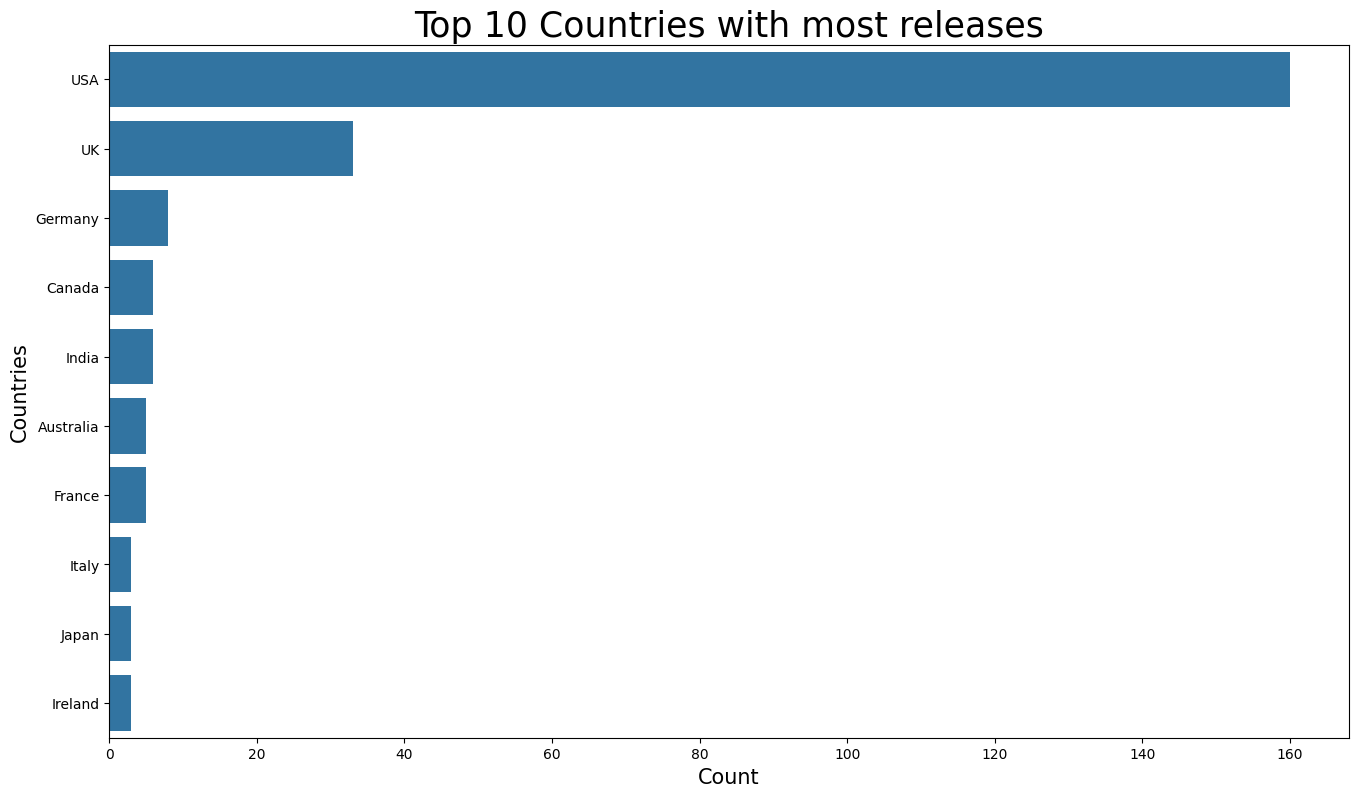

In [41]:
plt.figure(figsize = (16, 9))
ax = sns.barplot(x = 'count', y = 'country', data = country_counts.sort_values('count', ascending=False)[0:10])
plt.title("Top 10 Countries with most releases", fontsize = 25)
plt.xlabel('Count', fontsize = 15)
plt.ylabel('Countries', fontsize = 15)
plt.show()

## Top 10 Languages

In [42]:
language_series = df_new['language'].str.split(',\s*').explode()

# Count the occurrences of each genre
language_counts = language_series.value_counts().reset_index()

# Rename columns
language_counts.columns = ['language', 'count']
language_counts.head()

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\DELL\AppData\Local\Temp\ipykernel_22572\1660907727.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  language_series = df_new['language'].str.split(',\s*').explode()


,language,count
0,English,178
1,French,22
2,Spanish,22
3,German,19
4,Italian,11


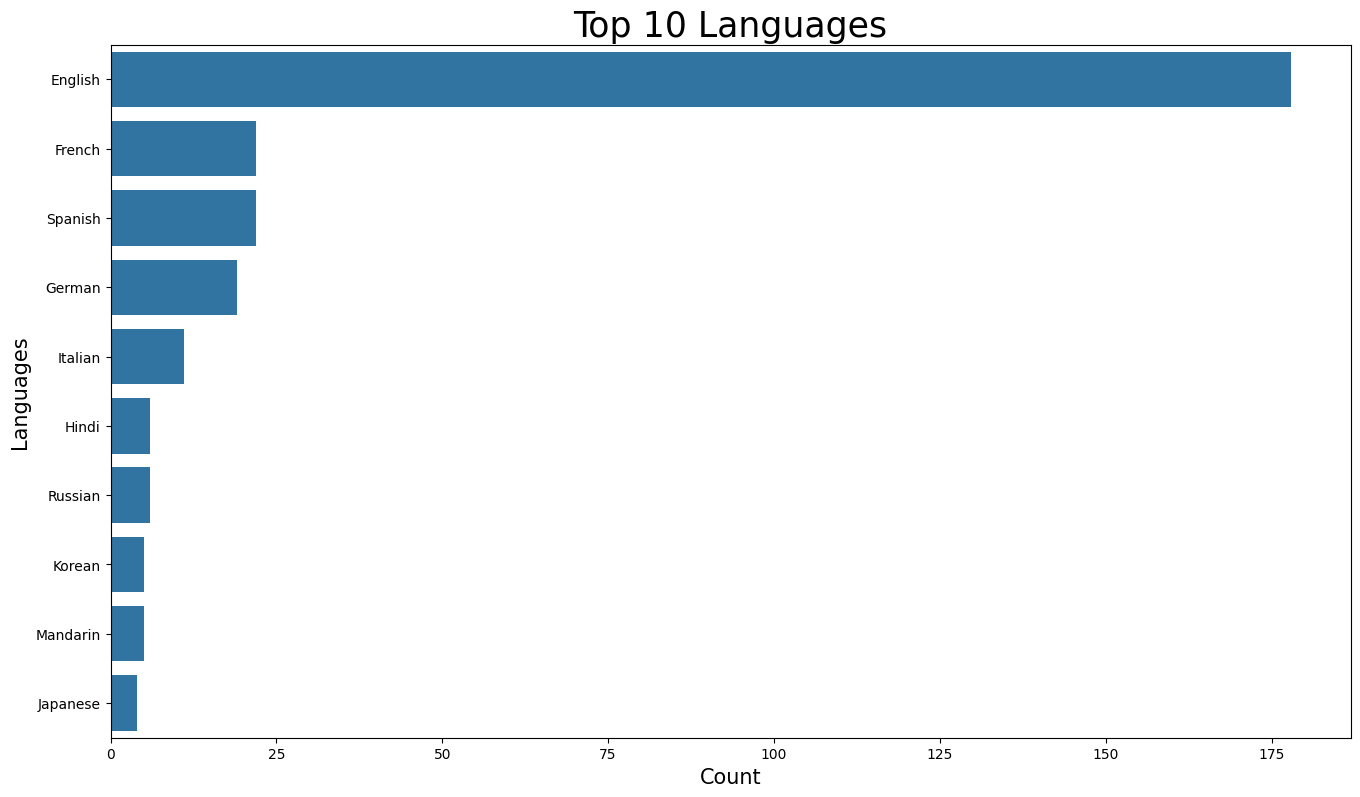

In [43]:
plt.figure(figsize = (16, 9))
ax = sns.barplot(x = 'count', y = 'language', data = language_counts.sort_values('count', ascending=False)[0:10])
plt.title("Top 10 Languages", fontsize = 25)
plt.xlabel('Count', fontsize = 15)
plt.ylabel('Languages', fontsize = 15)
plt.show()

## Top 10 Directors

In [44]:
director_series = df_new['director'].str.split(',\s*').explode()

# Count the occurrences of each genre
director_counts = director_series.value_counts().reset_index()

# Rename columns
director_counts.columns = ['director', 'count']
director_counts.head()

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\DELL\AppData\Local\Temp\ipykernel_22572\2157142991.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  director_series = df_new['director'].str.split(',\s*').explode()


,director,count
0,Christopher Nolan,6
1,Martin Scorsese,6
2,Steven Spielberg,5
3,Quentin Tarantino,4
4,David Fincher,4


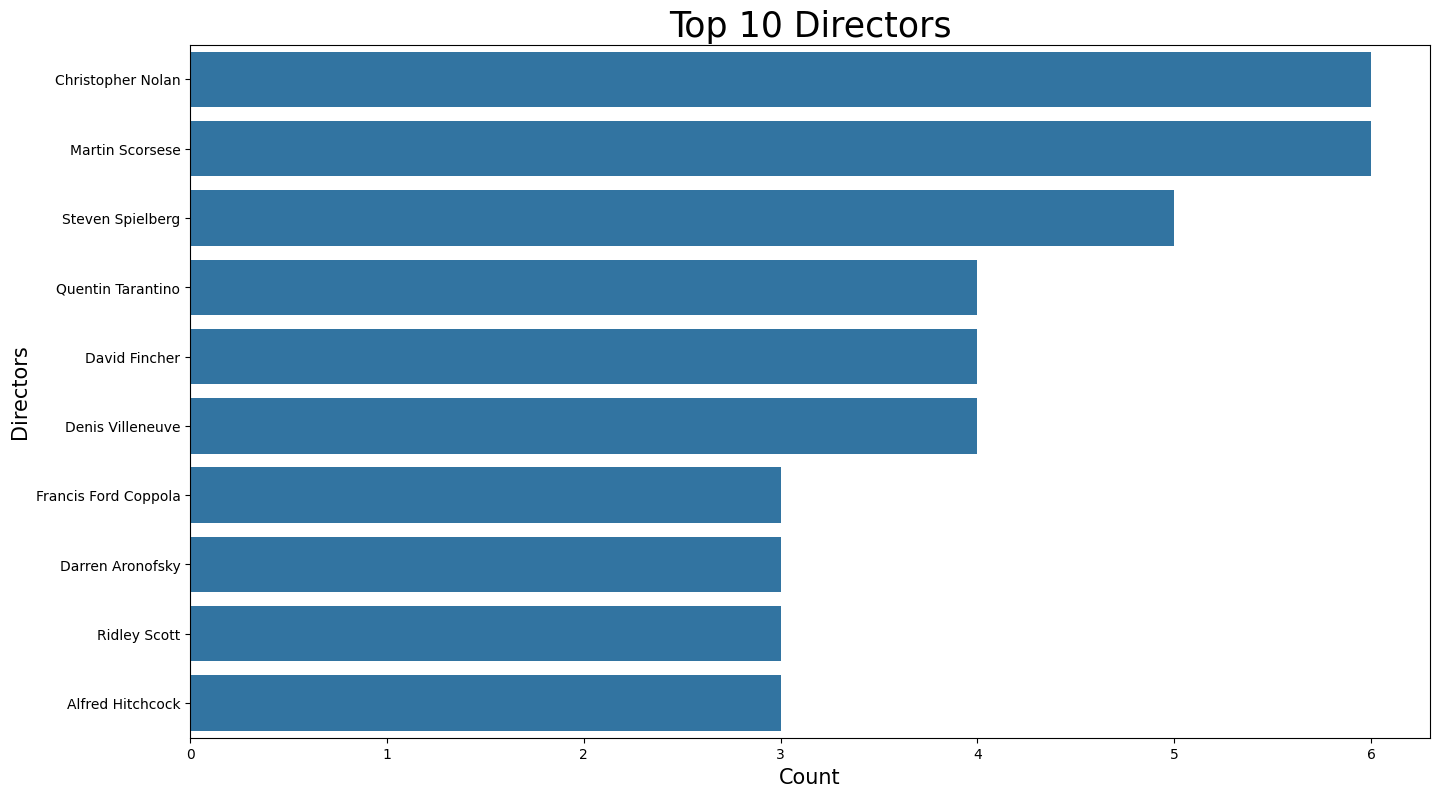

In [45]:
plt.figure(figsize = (16, 9))
ax = sns.barplot(x = 'count', y = 'director', data = director_counts.sort_values('count', ascending=False)[0:10])
plt.title("Top 10 Directors", fontsize = 25)
plt.xlabel('Count', fontsize = 15)
plt.ylabel('Directors', fontsize = 15)
plt.show()

## Wordcloud for Cast

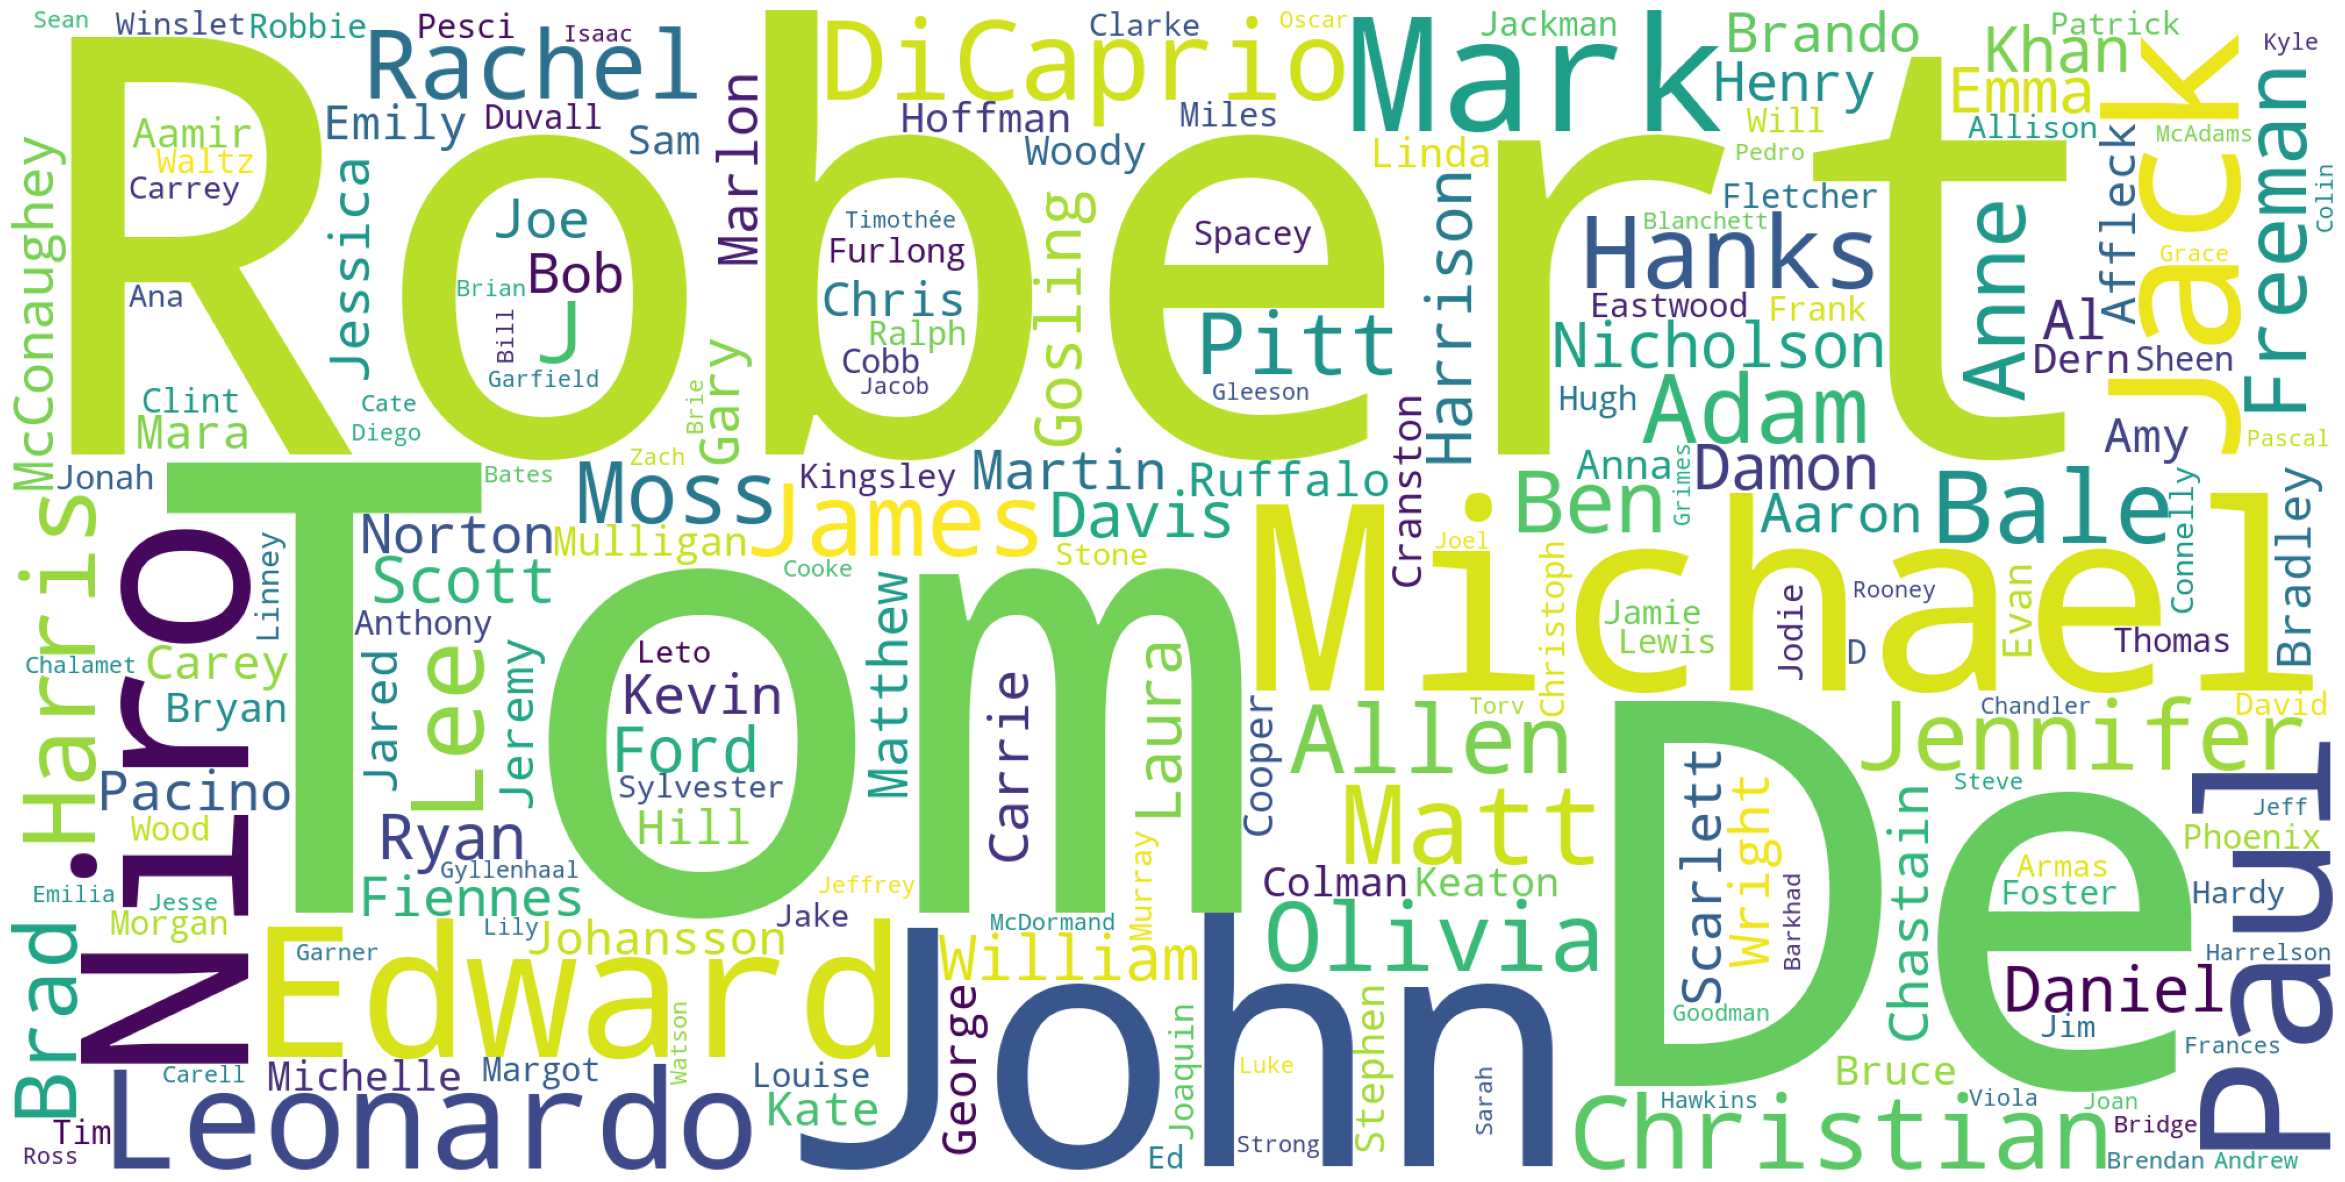

In [46]:
stop_words = set(stopwords.words('english'))
df_new.loc[:, 'cast_no_stopwords'] = df_new['cast'].apply(lambda x: [item for item in str(x).split() if item not in stop_words])

all_words = list([a for b in df_new['cast_no_stopwords'].tolist() for a in b])
all_words_str = ' '.join(all_words) 

def plot_cloud(wordcloud):
    plt.figure(figsize=(30, 20))
    plt.imshow(wordcloud) 
    plt.axis("off");

wordcloud = WordCloud(width = 2000, height = 1000, random_state=1, background_color='white', 
                      colormap='viridis', collocations=False).generate(all_words_str)
plot_cloud(wordcloud)

## Time series of Ratings

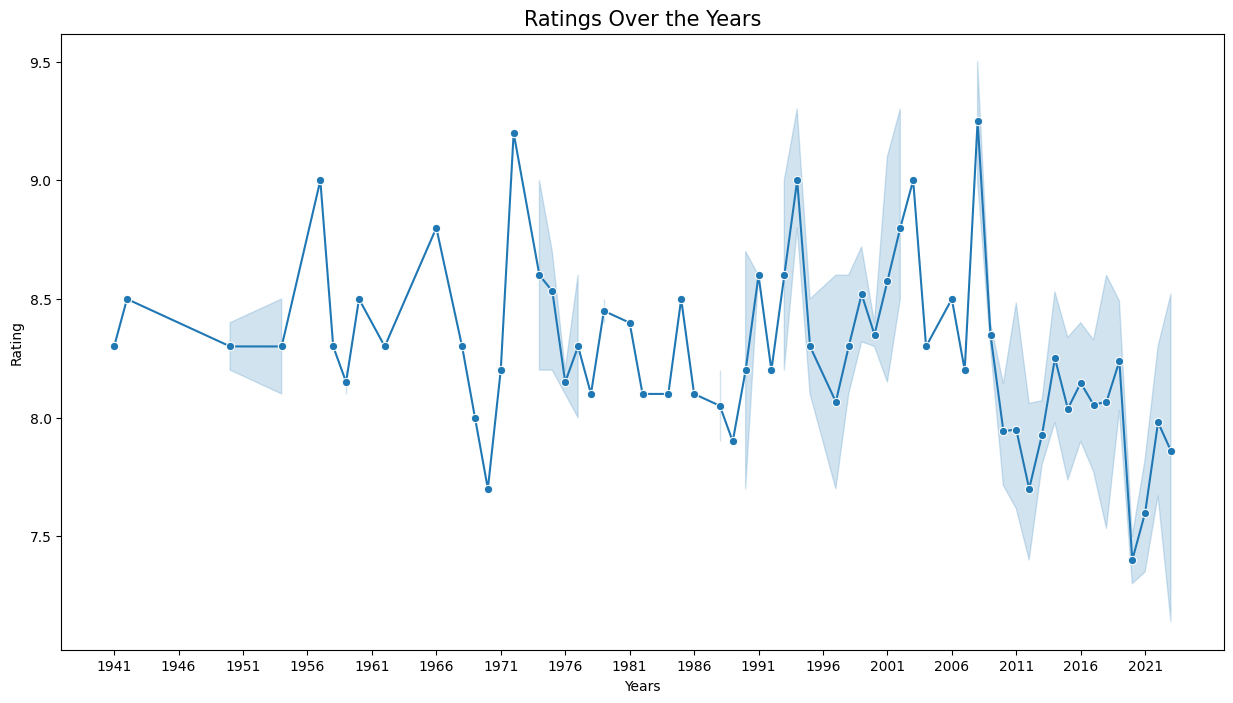

In [47]:
# Create a line chart using Seaborn
plt.figure(figsize=(15, 8))
ax = sns.lineplot(x='year', y='rating', data=df_new, marker='o')

# Set x-axis ticks for every 5 years
plt.xticks(range(df_new['year'].min(), df_new['year'].max() + 1, 5))

plt.xlabel('Years')
plt.ylabel('Rating')
plt.title('Ratings Over the Years', fontsize=15)
plt.show()

## Relationship between ratings and votes 

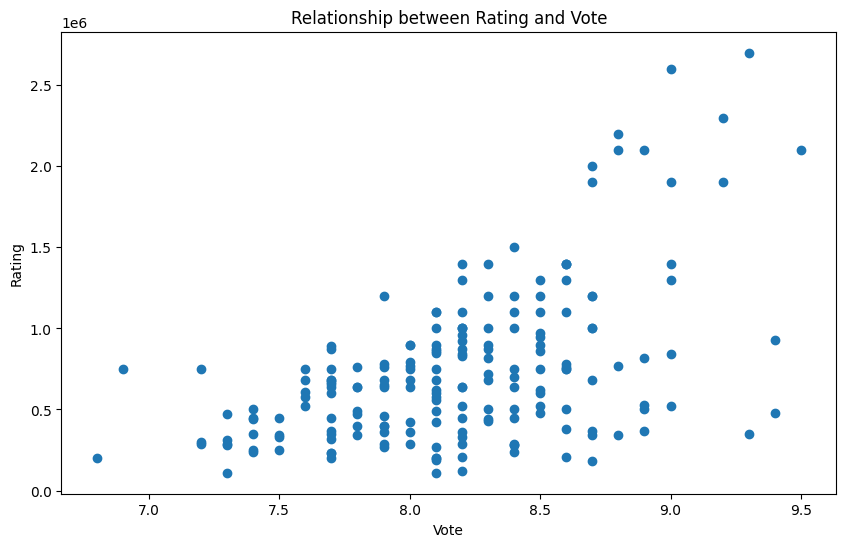

In [48]:
plt.figure(figsize=(10, 6))
plt.scatter(x = 'rating', y = 'vote', data = df_new)
plt.xlabel('Vote')
plt.ylabel('Rating')
plt.title('Relationship between Rating and Vote')
plt.show()